# Baseline Forecasting

This notebook evaluates simple seasonal forecasts for hourly Citi Bike pickup demand.

## Baselines

- Same hour yesterday: 24-hour lag
- Same hour last week: 168-hour lag

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
)


PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "hourly_pickups.parquet"
)

pickups = (
    pd.read_parquet(DATA_FILE)
    .sort_values(["station_id", "timestamp"])
    .reset_index(drop=True)
)

pickups.head()

,timestamp,station_id,station_name,pickups
0,2026-04-01 00:00:00,5374.01,Norfolk St & Broome St,4
1,2026-04-01 01:00:00,5374.01,Norfolk St & Broome St,2
2,2026-04-01 02:00:00,5374.01,Norfolk St & Broome St,3
3,2026-04-01 03:00:00,5374.01,Norfolk St & Broome St,1
4,2026-04-01 04:00:00,5374.01,Norfolk St & Broome St,1


In [2]:
pickups["lag_24"] = (
    pickups.groupby("station_id")["pickups"]
    .shift(24)
)

pickups["lag_168"] = (
    pickups.groupby("station_id")["pickups"]
    .shift(168)
)

pickups[
    [
        "timestamp",
        "station_id",
        "station_name",
        "pickups",
        "lag_24",
        "lag_168",
    ]
].head(175)

,timestamp,station_id,station_name,pickups,lag_24,lag_168
0,2026-04-01 00:00:00,5374.01,Norfolk St & Broome St,4,NaN,NaN
1,2026-04-01 01:00:00,5374.01,Norfolk St & Broome St,2,NaN,NaN
2,2026-04-01 02:00:00,5374.01,Norfolk St & Broome St,3,NaN,NaN
3,2026-04-01 03:00:00,5374.01,Norfolk St & Broome St,1,NaN,NaN
4,2026-04-01 04:00:00,5374.01,Norfolk St & Broome St,1,NaN,NaN
...,...,...,...,...,...,...
170,2026-04-08 02:00:00,5374.01,Norfolk St & Broome St,1,0.0,3.0
171,2026-04-08 03:00:00,5374.01,Norfolk St & Broome St,1,3.0,1.0
172,2026-04-08 04:00:00,5374.01,Norfolk St & Broome St,0,0.0,1.0
173,2026-04-08 05:00:00,5374.01,Norfolk St & Broome St,0,3.0,0.0


In [3]:
test_start = (
    pickups["timestamp"].max().normalize()
    - pd.Timedelta(days=6)
)

train = pickups[
    pickups["timestamp"] < test_start
].copy()

test = pickups[
    pickups["timestamp"] >= test_start
].copy()

print(f"Training ends: {train['timestamp'].max()}")
print(f"Testing starts: {test['timestamp'].min()}")
print(f"Testing ends: {test['timestamp'].max()}")
print(f"Test rows: {len(test):,}")

Training ends: 2026-04-23 23:00:00
Testing starts: 2026-04-24 00:00:00
Testing ends: 2026-04-30 23:00:00
Test rows: 4,200


In [4]:
baseline_results = pd.DataFrame(
    [
        {
            "model": "Same hour yesterday",
            "MAE": mean_absolute_error(
                test["pickups"],
                test["lag_24"],
            ),
            "RMSE": root_mean_squared_error(
                test["pickups"],
                test["lag_24"],
            ),
        },
        {
            "model": "Same hour last week",
            "MAE": mean_absolute_error(
                test["pickups"],
                test["lag_168"],
            ),
            "RMSE": root_mean_squared_error(
                test["pickups"],
                test["lag_168"],
            ),
        },
    ]
).sort_values("MAE")

baseline_results.style.format(
    {
        "MAE": "{:.2f}",
        "RMSE": "{:.2f}",
    }
)

,model,MAE,RMSE
1,Same hour last week,7.17,11.73
0,Same hour yesterday,8.04,12.84


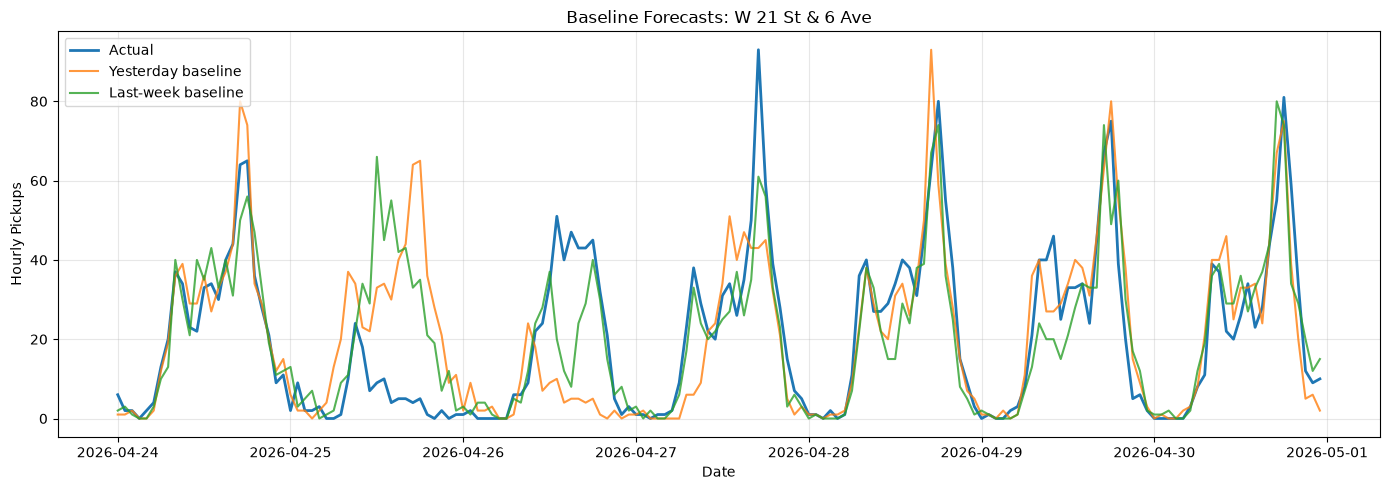

In [5]:
station_name = "W 21 St & 6 Ave"

station_test = test[
    test["station_name"] == station_name
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    station_test["timestamp"],
    station_test["pickups"],
    label="Actual",
    linewidth=2,
)

ax.plot(
    station_test["timestamp"],
    station_test["lag_24"],
    label="Yesterday baseline",
    alpha=0.8,
)

ax.plot(
    station_test["timestamp"],
    station_test["lag_168"],
    label="Last-week baseline",
    alpha=0.8,
)

ax.set_title(
    f"Baseline Forecasts: {station_name}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Hourly Pickups")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

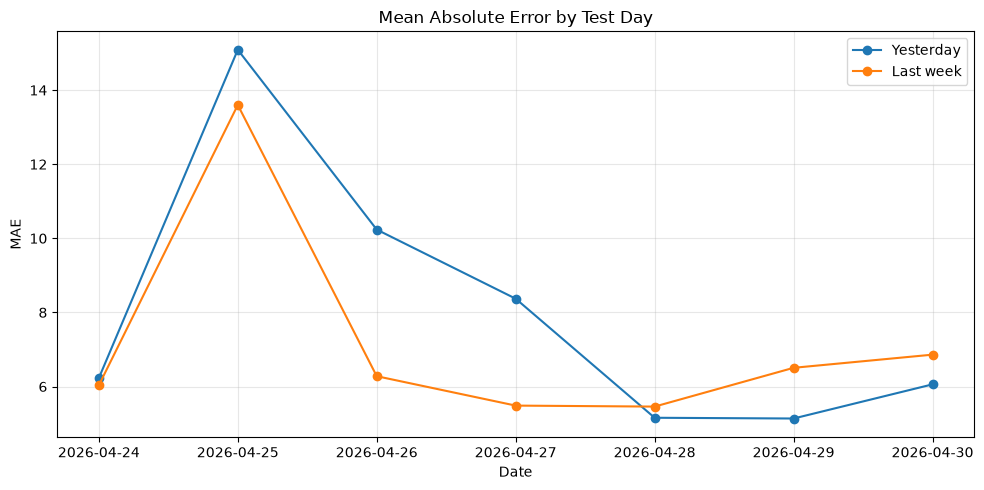

In [6]:
error_data = test.copy()

error_data["yesterday_absolute_error"] = (
    error_data["pickups"]
    - error_data["lag_24"]
).abs()

error_data["last_week_absolute_error"] = (
    error_data["pickups"]
    - error_data["lag_168"]
).abs()

error_data["date"] = (
    error_data["timestamp"].dt.date
)

daily_errors = (
    error_data.groupby("date")[
        [
            "yesterday_absolute_error",
            "last_week_absolute_error",
        ]
    ]
    .mean()
    .rename(
        columns={
            "yesterday_absolute_error": "Yesterday",
            "last_week_absolute_error": "Last week",
        }
    )
)

ax = daily_errors.plot(
    figsize=(10, 5),
    marker="o",
)

ax.set_title("Mean Absolute Error by Test Day")
ax.set_xlabel("Date")
ax.set_ylabel("MAE")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
station_errors = (
    error_data.groupby(
        ["station_id", "station_name"],
        as_index=False,
    )
    .agg(
        yesterday_mae=("yesterday_absolute_error", "mean"),
        last_week_mae=("last_week_absolute_error", "mean"),
        average_pickups=("pickups", "mean"),
        max_pickups=("pickups", "max"),
    )
)

station_errors["last_week_improvement"] = (
    station_errors["yesterday_mae"]
    - station_errors["last_week_mae"]
)

station_errors = station_errors.sort_values(
    "last_week_mae",
    ascending=False,
)

station_errors.style.format(
    {
        "yesterday_mae": "{:.2f}",
        "last_week_mae": "{:.2f}",
        "average_pickups": "{:.2f}",
        "max_pickups": "{:.0f}",
        "last_week_improvement": "{:.2f}",
    }
)

,station_id,station_name,yesterday_mae,last_week_mae,average_pickups,max_pickups,last_week_improvement
22,6876.04,Central Park S & 6 Ave,10.29,11.14,11.83,70,-0.85
24,6948.10,Broadway & W 58 St,8.26,10.94,14.37,60,-2.68
23,6912.01,7 Ave & Central Park South,8.46,9.57,14.73,72,-1.11
3,5788.13,Lafayette St & E 8 St,10.15,9.32,13.27,60,0.83
12,6233.04,Pier 61 at Chelsea Piers,7.89,8.21,17.67,67,-0.33
9,6140.05,W 21 St & 6 Ave,9.51,8.15,20.59,93,1.36
13,6331.01,W 31 St & 7 Ave,8.63,7.67,15.77,71,0.96
6,5980.10,E 17 St & Broadway,8.22,7.39,15.84,69,0.83
14,6364.07,6 Ave & W 33 St,7.83,7.07,13.88,61,0.76
5,5905.14,University Pl & E 14 St,7.45,6.96,14.36,48,0.48


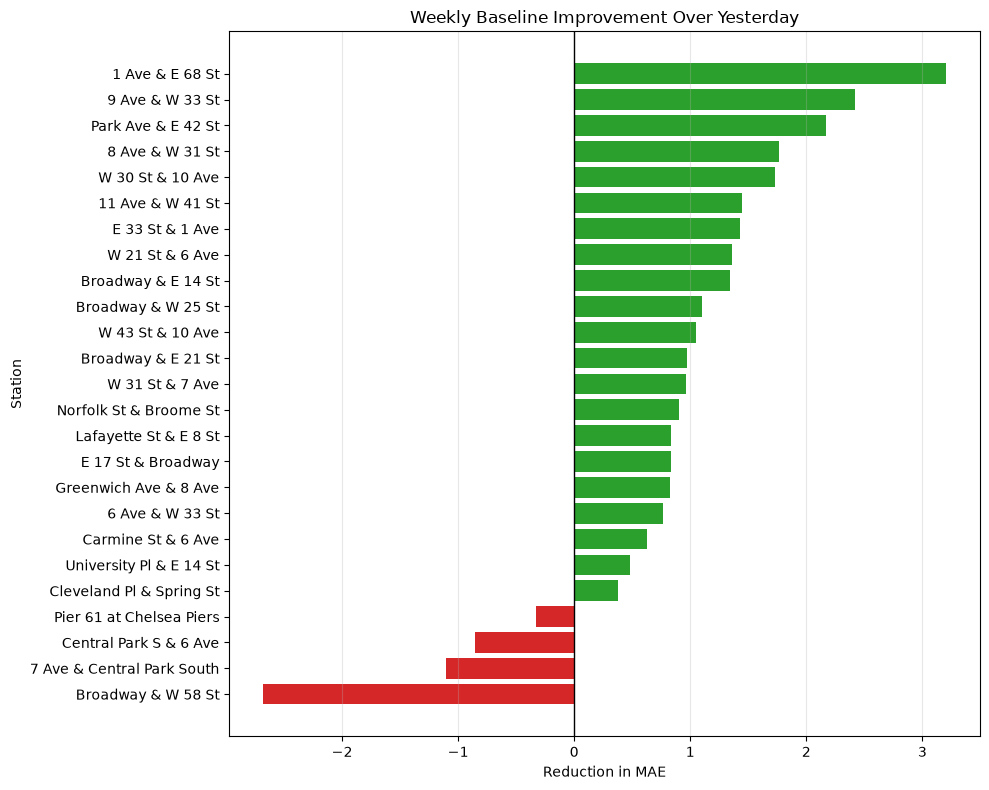

In [8]:
improvement_plot = station_errors.sort_values(
    "last_week_improvement"
)

colors = [
    "tab:green" if value > 0 else "tab:red"
    for value in improvement_plot[
        "last_week_improvement"
    ]
]

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(
    improvement_plot["station_name"],
    improvement_plot["last_week_improvement"],
    color=colors,
)

ax.axvline(0, color="black", linewidth=1)

ax.set_title(
    "Weekly Baseline Improvement Over Yesterday"
)
ax.set_xlabel("Reduction in MAE")
ax.set_ylabel("Station")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()